In [1]:
import geopandas as gpd
import gpxpy
import glob
import gpxpy.gpx
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import matplotlib.animation as animation
import numpy as np
from utils import *
import osmnx as ox
    

In [2]:
G = ox.graph.graph_from_place("Barcelone, Spain", network_type="drive")

In [9]:
Gracia = ox.graph.graph_from_place("Gracia, Barcelone, Spain", network_type="drive")

In [16]:
Guinardo = ox.graph.graph_from_place("Baix-Guinardo, Barcelone, Spain", network_type="drive")

In [43]:
%matplotlib widget

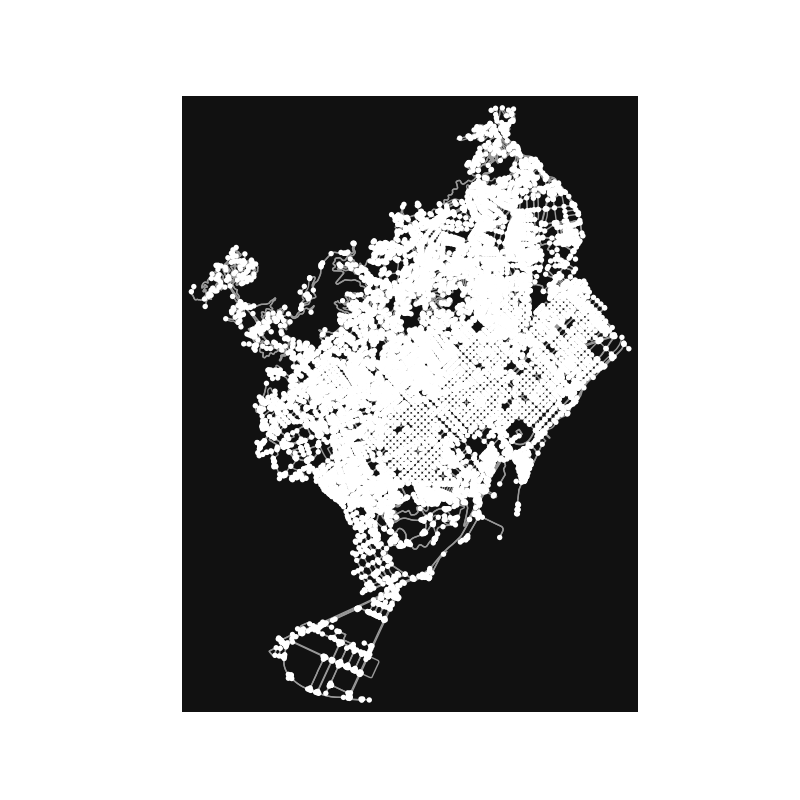

In [44]:
fig, ax = ox.plot.plot_graph(G)

In [12]:
%matplotlib inline

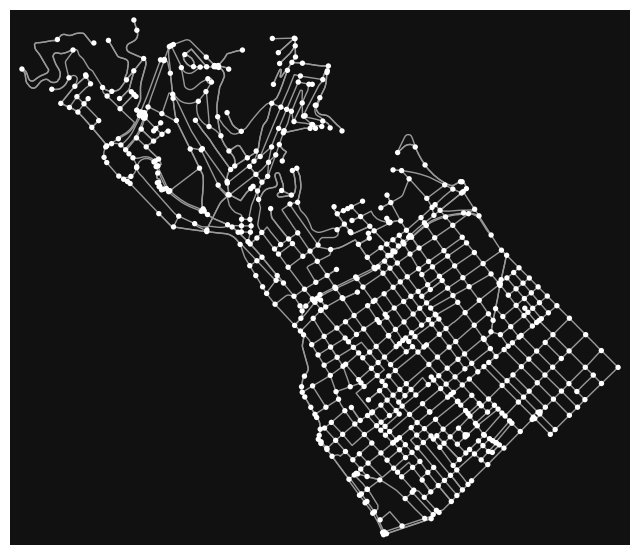

In [156]:
fig, ax = ox.plot.plot_graph(Gracia)

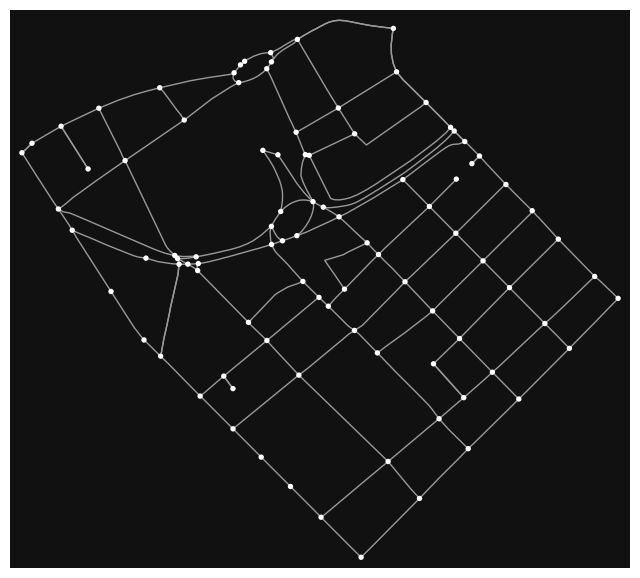

In [17]:
fig, ax = ox.plot.plot_graph(Guinardo)

In [18]:
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m = nodes_proj.union_all().convex_hull.area
Gracia_proj = ox.projection.project_graph(Gracia)
nodes_gracia_proj = ox.convert.graph_to_gdfs(Gracia_proj, edges=False)
graph_gracia_area_m = nodes_gracia_proj.union_all().convex_hull.area
graph_gracia_area_m = nodes_gracia_proj.union_all().convex_hull.area

In [10]:
stats = ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)
stats

{'n': 8896,
 'm': 16493,
 'k_avg': 3.7079586330935252,
 'edge_length_total': 1671639.3737025561,
 'edge_length_avg': 101.35447606272699,
 'streets_per_node_avg': 3.1551258992805757,
 'streets_per_node_counts': {0: 0,
  1: 644,
  2: 150,
  3: 5393,
  4: 2614,
  5: 81,
  6: 14},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.07239208633093525,
  2: 0.016861510791366906,
  3: 0.6062275179856115,
  4: 0.29383992805755393,
  5: 0.00910521582733813,
  6: 0.0015737410071942446},
 'intersection_count': 8252,
 'street_length_total': 1387740.5754353616,
 'street_segment_count': 13956,
 'street_length_avg': 99.43684260786483,
 'circuity_avg': 1.049535587137089,
 'self_loop_proportion': 0.0009314989968472342,
 'clean_intersection_count': 5853,
 'node_density_km': 75.4076603013751,
 'intersection_density_km': 69.94874244682411,
 'edge_density_km': 14169.78575073806,
 'street_density_km': 11763.29472783999,
 'clean_intersection_density_km': 49.61342578056974}

In [158]:
total_street_length = stats["edge_length_total"]/1000.
total_street_length


1671.6393737025562

In [20]:
stats_gracia = ox.stats.basic_stats(Gracia_proj, area=graph_gracia_area_m, clean_int_tol=15)
total_street_length_gracia = stats_gracia["edge_length_total"]/1000.
total_street_length_gracia
stats_gracia

{'n': 745,
 'm': 1324,
 'k_avg': 3.5543624161073826,
 'edge_length_total': 110567.0538273144,
 'edge_length_avg': 83.50985938618913,
 'streets_per_node_avg': 3.1369127516778526,
 'streets_per_node_counts': {0: 0, 1: 64, 2: 12, 3: 434, 4: 229, 5: 5, 6: 1},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.08590604026845637,
  2: 0.016107382550335572,
  3: 0.5825503355704698,
  4: 0.3073825503355705,
  5: 0.006711409395973154,
  6: 0.0013422818791946308},
 'intersection_count': 681,
 'street_length_total': 91911.29299080143,
 'street_segment_count': 1123,
 'street_length_avg': 81.84442830881694,
 'circuity_avg': 1.03720567660894,
 'self_loop_proportion': 0.0,
 'clean_intersection_count': 529,
 'node_density_km': 6.3150524870193845,
 'intersection_density_km': 5.772551333772082,
 'edge_density_km': 937.2305345699168,
 'street_density_km': 779.0934756868832,
 'clean_intersection_density_km': 4.484111094809737}

In [159]:
node_id = list(G.nodes)[0]
G.nodes[node_id]

{'y': 41.3700925, 'x': 2.187743, 'street_count': 3}

In [45]:
nth_edge = 5
print("Attributes for the first",nth_edge,"edges")
for i, (u, v, k, data) in enumerate(G.edges(keys=True, data=True)):
    print(f"Edge ({u}, {v}, {k}):")
    print(data["name"])
    for key, value in data.items():
        print(f"  - {key}: {value}")
    
    if i >= nth_edge:
        break

Attributes for the first 5 edges
Edge (21638845, 885308258, 0):
Passeig de Joan de Borbó
  - osmid: 554707785
  - highway: residential
  - lanes: 2
  - maxspeed: 30
  - name: Passeig de Joan de Borbó
  - oneway: True
  - reversed: False
  - length: 28.33475962697731
Edge (21638845, 13175411896, 0):
Passeig de Joan de Borbó
  - osmid: [1433594636, 4079500, 543357596, 902517725, 423227070]
  - highway: residential
  - lanes: ['4', '3']
  - maxspeed: 30
  - name: Passeig de Joan de Borbó
  - oneway: False
  - reversed: True
  - length: 616.4811590433035
  - geometry: LINESTRING (2.187743 41.3700925, 2.1876862 41.3701691, 2.187646 41.3702497, 2.1876269 41.3702846, 2.1875931 41.3703647, 2.1876124 41.3705394, 2.1876143 41.3705512, 2.187617 41.3705677, 2.1876623 41.3708496, 2.1876664 41.3708748, 2.1877927 41.3716585, 2.1877969 41.3716845, 2.1879173 41.3724315, 2.1879222 41.3724622, 2.1879268 41.372491, 2.1879373 41.3725507, 2.1879812 41.3728904, 2.1880545 41.3733609, 2.1880724 41.3734818, 2.1

In [46]:
edge_number = 6
nth_edge = None
edge_iterator = iter(G.edges(keys=True))

for _ in range(edge_number + 1):
        nth_edge = next(edge_iterator)
    
print("edge ", edge_number,nth_edge)


edge  6 (21638868, 30343649, 0)


In [47]:
coords_casa = [41.400971,2.160001] #from gmaps
coords_casa_hub = [41.4152636,2.1648925]

In [48]:
#test if lat,lon falls back on right street name
# 
u, v, k = ox.nearest_edges(
    G, 
    X=coords_casa[1], 
    Y=coords_casa[0]
)
print(u,v,k)
edge_attributes = G.get_edge_data(u, v, k)
edge_attributes.get('name')

30254379 30333334 0


'Carrer de la Fraternitat'

In [49]:
u, v, k = ox.nearest_edges(
    G, 
    X=coords_casa_hub[1], 
    Y=coords_casa_hub[0]
)
print(u,v,k)
edge_attributes = G.get_edge_data(u, v, k)
edge_attributes.get('name')

849592994 30688839 0


'Carrer de Polònia'

In [112]:
def get_edge_from_coords(coords):
    u, v, k = ox.nearest_edges(
    G, 
    X=coords[1], 
    Y=coords[0]
    )
    print(u,v,k)
    edge_attributes = G.get_edge_data(u, v, k)
    if type(edge_attributes.get('name')) == str:  
        street_name = edge_attributes.get('name') 
    else:
        try:
            street_name = edge_attributes.get('name')[0]
            #
        except:
            street_name = "Unkwonw"
    print(type(street_name),street_name)

    return((u,v,k),street_name)
    

In [113]:
edge_casa , street_name_casa = get_edge_from_coords(coords_casa)
edge_hub ,street_name_hub = get_edge_from_coords(coords_casa_hub)

30254379 30333334 0
<class 'str'> Carrer de la Fraternitat
849592994 30688839 0
<class 'str'> Carrer de Polònia


In [114]:
nodes_gdf, edges_gdf = ox.convert.graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True, fill_edge_geometry=True)
print("node0:",nodes_gdf.iloc[0])
print("edge0:",edges_gdf.iloc[0])

node0: y                                 41.370092
x                                  2.187743
street_count                              3
ref                                     NaN
highway                                 NaN
junction                                NaN
railway                                 NaN
geometry        POINT (2.187743 41.3700925)
Name: 21638845, dtype: object
edge0: osmid                                                554707785
highway                                            residential
lanes                                                        2
maxspeed                                                    30
name                                  Passeig de Joan de Borbó
oneway                                                    True
reversed                                                 False
length                                                28.33476
geometry     LINESTRING (2.187743 41.3700925, 2.1877072 41....
access                               

In [115]:
def get_coords_gpx(user,n_segments=None):
    file = glob.glob(f'segments/{user}/*.gpx')[0] 
    gpx_file = open(file, 'r') 
    gpx = gpxpy.parse(gpx_file) 
    coords_gpx = []
    for track in gpx.tracks:
        for s, segment in enumerate(gpx.tracks[0].segments):
            if (user == 'hubert') & (s in [1, 6]):
                continue
            if n_segments and s >= n_segments:
                return coords_gpx
            for points in segment.points:
                coords_gpx.append((points.latitude,points.longitude))
    return coords_gpx



In [116]:
coords_gpx_pa = get_coords_gpx("pa")
len(coords_gpx_pa)

5022

In [100]:
#from hub, not useful any more, replaced by get_ccords_gpx
#track, lons, lats = load_long_lat("pa")
#track[1]

In [102]:
print(G.nodes[1396408887]['y'],G.nodes[1396408887]['x'])
print(G.nodes[30555974]['y'],G.nodes[30555974]['x'])


41.4049091 2.1738864
41.4052928 2.1755545


In [117]:
#list_edges = [edge_casa,edge_hub]
list_edges = set()
i=0
print("type1",type(coords_gpx_pa))
for lat, lon in coords_gpx_pa:
    print(i)
    edge_and_name = get_edge_from_coords((lat,lon))
    print("type",type(edge_and_name))
    print("edge_and_name",edge_and_name)
    if edge_and_name not in list_edges:
        list_edges.add(edge_and_name)
       # list_edges[i]
        #if in new edge, add to the list of edges 
    else:
        print("repeated")
        #shows the number of points per edges
    i=i+1
list_edges

type1 <class 'list'>
0
126797329 126803368 0
<class 'str'> Carrer de Provença
type <class 'tuple'>
edge_and_name ((126797329, 126803368, 0), 'Carrer de Provença')
1
30243117 126797329 0
<class 'str'> Carrer de Provença
type <class 'tuple'>
edge_and_name ((30243117, 126797329, 0), 'Carrer de Provença')
2
30243117 126797329 0
<class 'str'> Carrer de Provença
type <class 'tuple'>
edge_and_name ((30243117, 126797329, 0), 'Carrer de Provença')
repeated
3
30243117 126797329 0
<class 'str'> Carrer de Provença
type <class 'tuple'>
edge_and_name ((30243117, 126797329, 0), 'Carrer de Provença')
repeated
4
30243117 126797329 0
<class 'str'> Carrer de Provença
type <class 'tuple'>
edge_and_name ((30243117, 126797329, 0), 'Carrer de Provença')
repeated
5
30243117 126797329 0
<class 'str'> Carrer de Provença
type <class 'tuple'>
edge_and_name ((30243117, 126797329, 0), 'Carrer de Provença')
repeated
6
30243160 30243117 0
<class 'str'> Carrer de Provença
type <class 'tuple'>
edge_and_name ((30243160,

TypeError: 'NoneType' object is not subscriptable

In [94]:
problematic_edge = [30555974, 1396408887, 0]
problematic_edge_attributes=G.get_edge_data(30555974, 1396408887, 0)

problematic_edge_attributes.get('name')[0]

'Carrer de la Marina'

In [ ]:

highlighted_edges = set(list_edges)

# 2. Iterate through ALL edges in the graph and assign a color
edge_colors = []
for u, v, k in G.edges(keys=True):
    # The edge identifier is the tuple (u, v, k)
    edge_id = (u, v, k)
    
    if edge_id in highlighted_edges:
        # Assign red if the edge is in your list
        edge_colors.append("r")
    else:
        # Assign black if the edge is NOT in your list
        edge_colors.append("k")

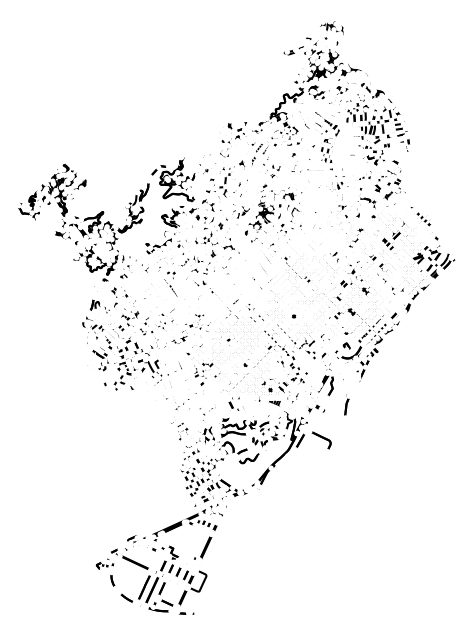

In [94]:
fig, ax = ox.plot.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=1.5,
    show=True,
    close=True,
    bgcolor="w"
)